# Yield Curve Construction with Principal Component Analysis

Identify the small number of latent factors that explain movements in the U.S. Treasury yield curve, then reconstruct the curve using only those factors.

## Overview

The U.S. Treasury curve contains highly correlated yields across maturities. This project applies principal component analysis (PCA) to reduce the nine-dimensional yield curve to a small set of interpretable factors.

The workflow covers automated data collection from the Federal Reserve Bank of St. Louis (FRED), data quality checks, exploratory analysis, standardization, PCA, factor interpretation, and reconstruction of the original yield levels from the leading components.

## 1. Data and Research Question

**Research question:** How many underlying factors are needed to explain most of the variation in the U.S. Treasury yield curve?

The analysis uses daily Treasury Constant Maturity Rates from FRED for nine maturities, ranging from 1 month to 30 years, over January 2000 to December 2024.

The nine maturities are:

- 1 month
- 3 months
- 6 months
- 2 years
- 3 years
- 5 years
- 7 years
- 20 years
- 30 years

PCA is used to identify the dominant dimensions of yield-curve variation and to assess how accurately the curve can be represented using only the leading components.

## 2. Libraries and Data Collection

In [1]:
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pandas_datareader.fred import FredReader
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
pd.set_option("display.precision", 3)
sns.set_theme(style="whitegrid")

In [2]:
# FRED Treasury Constant Maturity Rate series
fred_codes = {
    "TRESY1mo": "DGS1MO",
    "TRESY3mo": "DGS3MO",
    "TRESY6mo": "DGS6MO",
    "TRESY2y": "DGS2",
    "TRESY3y": "DGS3",
    "TRESY5y": "DGS5",
    "TRESY7y": "DGS7",
    "TRESY20y": "DGS20",
    "TRESY30y": "DGS30",
}

start_date = datetime(2000, 1, 1)
end_date = datetime(2024, 12, 31)

series = []
for name, code in fred_codes.items():
    reader = FredReader(code, start=start_date, end=end_date)
    s = reader.read().rename(columns={code: name})
    series.append(s)

dataset = pd.concat(series, axis=1).sort_index()

print(f"Observations: {len(dataset):,}")
print(f"Tenors: {dataset.shape[1]}")
print(f"Period: {dataset.index.min().date()} to {dataset.index.max().date()}")

Observations: 6,522
Tenors: 9
Period: 2000-01-03 to 2024-12-31


## 3. Data Quality and Exploratory Analysis

In [3]:
quality = pd.DataFrame({
    "missing": dataset.isna().sum(),
    "missing_pct": dataset.isna().mean().mul(100),
    "mean": dataset.mean(),
    "std": dataset.std()
})
quality

,missing,missing_pct,mean,std
TRESY1mo,665,10.196,1.552,1.790
TRESY3mo,269,4.125,1.854,1.986
TRESY6mo,269,4.125,1.953,1.985
TRESY2y,269,4.125,2.198,1.773
TRESY3y,269,4.125,2.372,1.663
TRESY5y,269,4.125,2.728,1.498
TRESY7y,269,4.125,3.030,1.399
TRESY20y,269,4.125,3.796,1.302
TRESY30y,269,4.125,3.874,1.179


In [4]:
# Remove incomplete observations before PCA
dataset = dataset.dropna().copy()

print(f"Clean observations: {len(dataset):,}")
print(f"Remaining missing values: {dataset.isna().sum().sum()}")

Clean observations: 5,857
Remaining missing values: 0


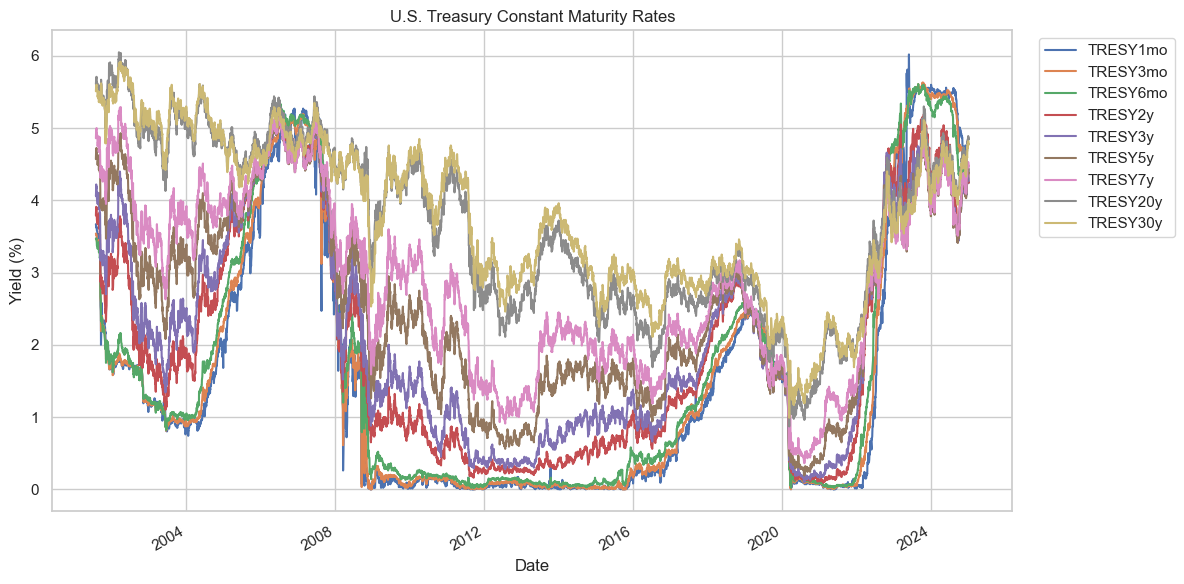

In [5]:
ax = dataset.plot(figsize=(12, 6))
ax.set_title("U.S. Treasury Constant Maturity Rates")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

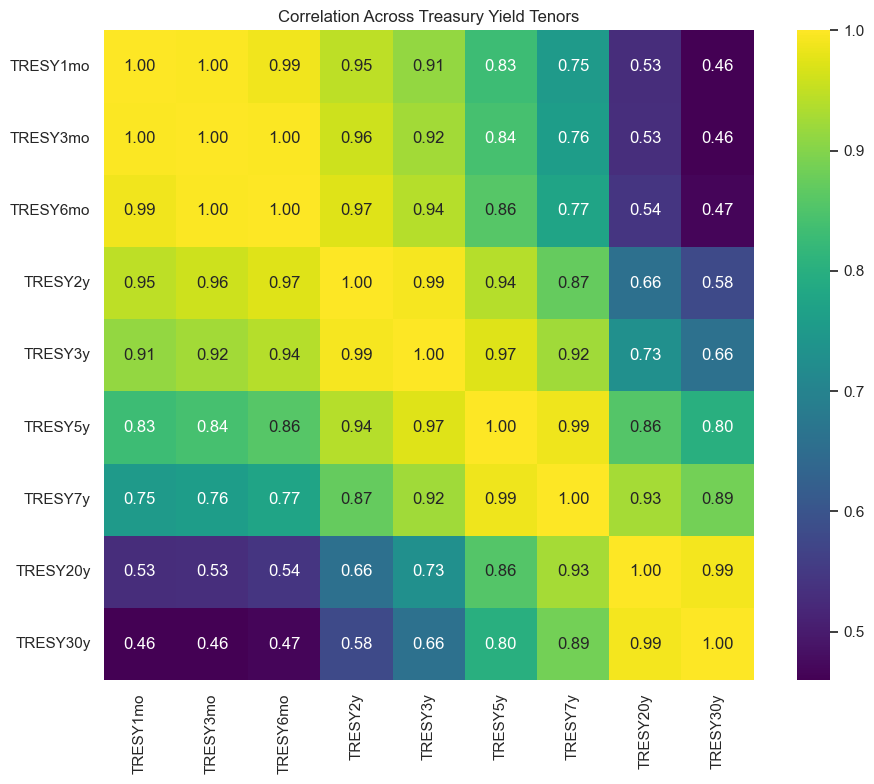

In [6]:
correlation = dataset.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, fmt=".2f", square=True, cmap="viridis")
plt.title("Correlation Across Treasury Yield Tenors")
plt.tight_layout()
plt.show()

The yield series are highly correlated across maturities. This motivates dimensionality reduction: much of the information contained in nine individual yields may be represented by a smaller number of common factors.

## 4. Standardization

In [7]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(dataset),
    columns=dataset.columns,
    index=dataset.index
)
X_scaled.head()

,TRESY1mo,TRESY3mo,TRESY6mo,TRESY2y,TRESY3y,TRESY5y,TRESY7y,TRESY20y,TRESY30y
DATE,,,,,,,,,
2001-07-31,1.183,1.065,0.972,1.156,1.300,1.548,1.641,1.640,1.607
2001-08-01,1.172,1.059,0.972,1.181,1.321,1.586,1.674,1.657,1.625
2001-08-02,1.172,1.059,0.966,1.219,1.375,1.639,1.731,1.698,1.662
2001-08-03,1.161,1.054,0.972,1.232,1.409,1.662,1.747,1.715,1.680
2001-08-06,1.155,1.054,0.972,1.213,1.375,1.654,1.747,1.715,1.680


Standardization puts each tenor on a common scale before PCA so that differences in the variance of individual maturities do not mechanically determine the principal components.

## 5. Principal Component Analysis

In [8]:
pca = PCA()
scores = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    "component": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "explained_variance": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})
explained_variance

,component,explained_variance,cumulative_variance
0,1,8.376e-01,0.838
1,2,1.469e-01,0.985
2,3,1.319e-02,0.998
3,4,1.239e-03,0.999
4,5,5.550e-04,1.000
5,6,3.324e-04,1.000
6,7,6.899e-05,1.000
7,8,4.547e-05,1.000
8,9,2.122e-05,1.000


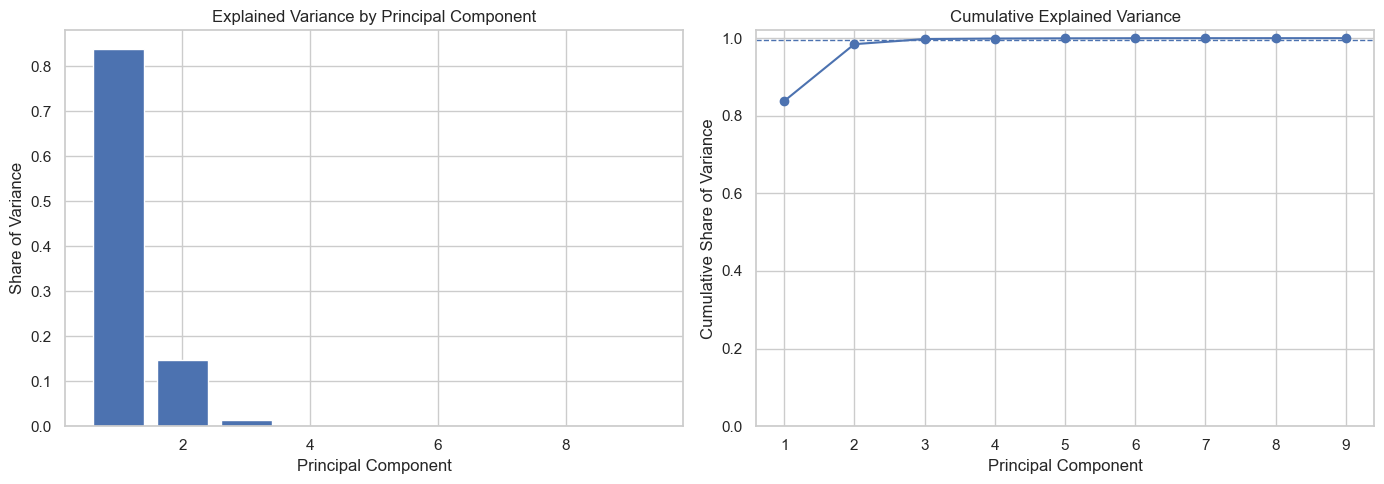

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    explained_variance["component"],
    explained_variance["explained_variance"]
)
axes[0].set_title("Explained Variance by Principal Component")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Share of Variance")

axes[1].plot(
    explained_variance["component"],
    explained_variance["cumulative_variance"],
    marker="o"
)
axes[1].axhline(0.995, linestyle="--", linewidth=1)
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("Cumulative Share of Variance")
axes[1].set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

The first three principal components explain more than **99.5%** of the variation in the standardized yield curve. This indicates that the nine-dimensional curve can be represented very accurately using three factors.

## 6. Interpreting the Principal Components

In [10]:
loadings = pd.DataFrame(
    pca.components_[:3].T,
    index=dataset.columns,
    columns=["PC1", "PC2", "PC3"]
)
loadings

,PC1,PC2,PC3
TRESY1mo,0.332,-0.330,0.444
TRESY3mo,0.334,-0.331,0.326
TRESY6mo,0.337,-0.320,0.169
TRESY2y,0.353,-0.185,-0.295
TRESY3y,0.359,-0.086,-0.415
TRESY5y,0.358,0.106,-0.387
TRESY7y,0.348,0.243,-0.260
TRESY20y,0.295,0.503,0.220
TRESY30y,0.274,0.560,0.379


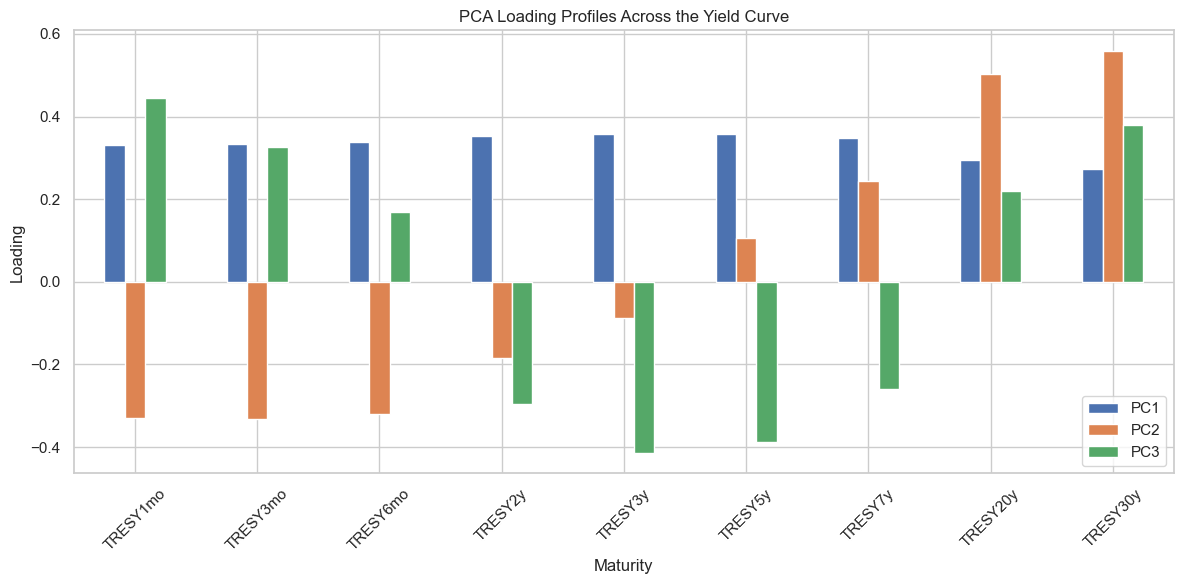

In [11]:
ax = loadings.plot(kind="bar", figsize=(12, 6))
ax.set_title("PCA Loading Profiles Across the Yield Curve")
ax.set_xlabel("Maturity")
ax.set_ylabel("Loading")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The loading profiles provide an economic interpretation of the leading factors:

- **PC1 - Level:** broadly common movement across maturities, capturing parallel shifts in the curve.
- **PC2 - Slope:** different weights on short and long maturities, capturing steepening and flattening.
- **PC3 - Curvature:** different weights on the middle of the curve relative to the short and long ends, capturing changes in curvature.

The sign of a principal component is arbitrary; interpretation therefore focuses on the relative loading pattern rather than the sign itself.

## 7. Curve Reconstruction

In [12]:
n_components = 3

scores_reduced = np.zeros_like(scores)
scores_reduced[:, :n_components] = scores[:, :n_components]

reconstructed_scaled = pca.inverse_transform(scores_reduced)
reconstructed = pd.DataFrame(
    scaler.inverse_transform(reconstructed_scaled),
    columns=dataset.columns,
    index=dataset.index
)

reconstruction_error = dataset - reconstructed
rmse = np.sqrt((reconstruction_error ** 2).mean())
rmse

TRESY1mo    0.107
TRESY3mo    0.045
TRESY6mo    0.095
TRESY2y     0.082
TRESY3y     0.040
TRESY5y     0.049
TRESY7y     0.067
TRESY20y    0.067
TRESY30y    0.054
dtype: float64

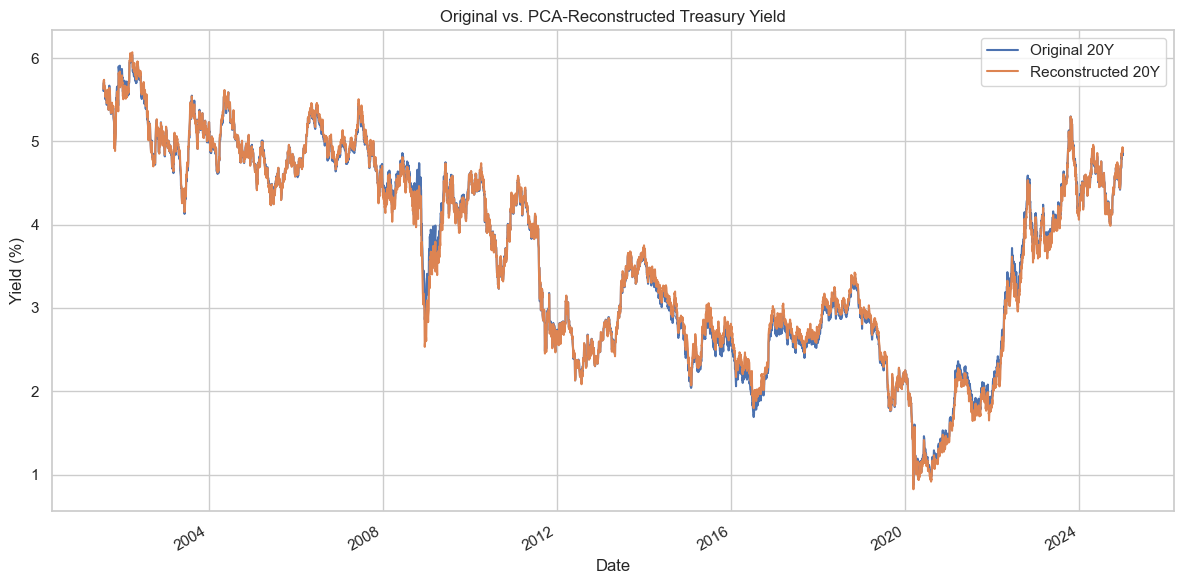

In [13]:
comparison = pd.DataFrame({
    "Original 20Y": dataset["TRESY20y"],
    "Reconstructed 20Y": reconstructed["TRESY20y"]
})

ax = comparison.plot(figsize=(12, 6))
ax.set_title("Original vs. PCA-Reconstructed Treasury Yield")
ax.set_xlabel("Date")
ax.set_ylabel("Yield (%)")
plt.tight_layout()
plt.show()

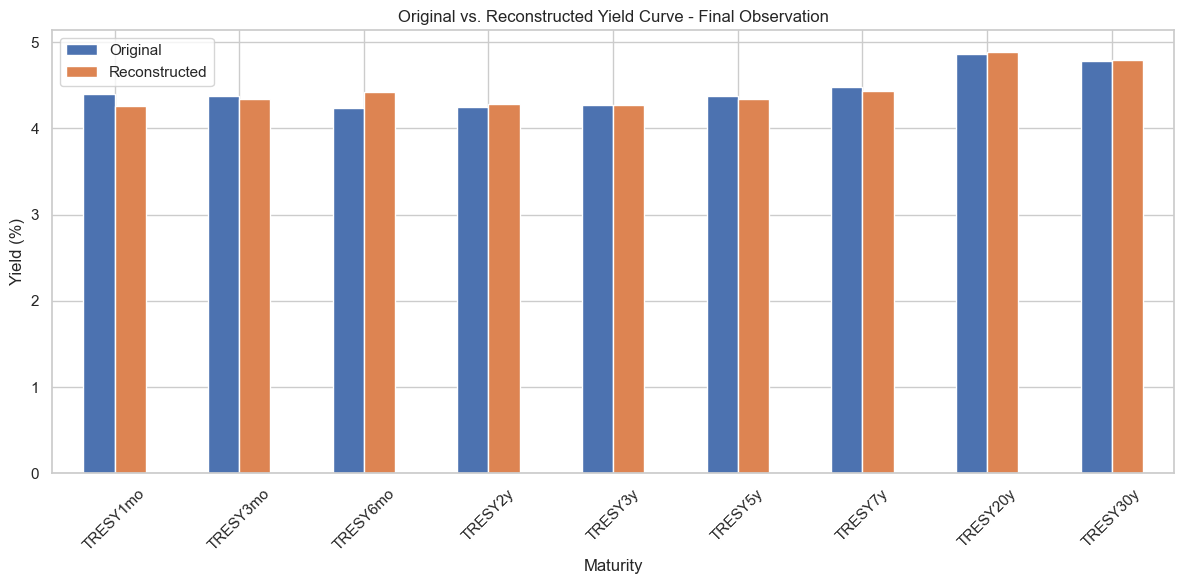

In [14]:
comparison_curve = pd.DataFrame({
    "Original": dataset.iloc[-1],
    "Reconstructed": reconstructed.iloc[-1]
})

comparison_curve.plot(kind="bar", figsize=(12, 6))
plt.title("Original vs. Reconstructed Yield Curve - Final Observation")
plt.xlabel("Maturity")
plt.ylabel("Yield (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Using only the first three components preserves almost all of the variation in the yield curve. The reconstruction is mapped back to the original yield units by reversing both the PCA transformation and the initial standardization.

## 8. Key Takeaway

PCA reduces the nine Treasury yield tenors to three economically interpretable factors - **level, slope, and curvature** - while retaining more than **99.5%** of the variation in the data.

The project demonstrates an end-to-end financial data workflow: automated API-based data collection, data quality checks, dimensionality reduction, economic interpretation, and reconstruction-based validation.